# TIỀN XỬ LÝ VÀ LÀM SẠCH DỮ LIỆU RƯỢU VANG (DATA CLEANING & PREPROCESSING)

Dự án: **Phân tích và Đối sánh Chất lượng Rượu Vang (Wine Quality Analysis)**  
Nguồn dữ liệu: **UCI Machine Learning Repository** (bao gồm Vang đỏ và Vang trắng)

---

### Mục tiêu của Notebook:
1. Nạp dữ liệu thô và trực quan hóa phân phối hàng-cột ban đầu.
2. Chuẩn hóa tên cột sang tiếng Việt rõ ràng, nhất quán.
3. Kiểm tra tính toàn vẹn của dữ liệu: giá trị thiếu (*Missing Values*) và bản ghi trùng lặp (*Duplicates*).
4. Xử lý giá trị ngoại lai (*Outliers*) bằng kỹ thuật **Winsorization / Capping (1% - 99%)** nhằm bảo tồn 100% số lượng quan sát.
5. Đối chiếu trực quan phân phối trước và sau khi làm mịn ngoại lai.
6. Tạo biến phân loại 3 bậc chất lượng và xuất sang định dạng nén nhị phân **Feather** (`data/duleu_chuan.feather`).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.data_loader import doc_du_lieu_goc, luu_du_lieu_chuan
from src.cleaner import (
    chuan_hoa_ten_cot,
    kiem_tra_chat_luong_du_lieu,
    xu_ly_ngoai_lai_capping,
    tao_bien_phan_bac_chat_luong,
    CAC_COT_HOA_LY
)
from src.visualizer import plotPerColumnDistribution

%matplotlib inline
print("[INFO] Đã nạp thành công các module cần thiết từ src/")

[INFO] Đã nạp thành công các module cần thiết từ src/


## Bước 1: Nạp Dữ Liệu Thô (Raw Data)
Đọc dữ liệu gốc đã gộp cả vang đỏ và vang trắng từ `data/chatluong_ruougoc.csv`.

In [1]:
df_goc = doc_du_lieu_goc()
print(f"Kích thước tập dữ liệu thô: {df_goc.shape[0]} dòng, {df_goc.shape[1]} cột")
df_goc.head(5)

Kích thước tập dữ liệu thô: 6497 dòng, 13 cột


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,loai_ruou
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Vang đỏ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Vang đỏ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Vang đỏ
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Vang đỏ
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Vang đỏ


## Bước 2: Trực Quan Hóa Phân Phối Dữ Liệu Thô (Trước Khi Làm Sạch)
Sử dụng hàm `plotPerColumnDistribution` để kiểm tra phân phối cột theo dạng lưới hàng-cột.

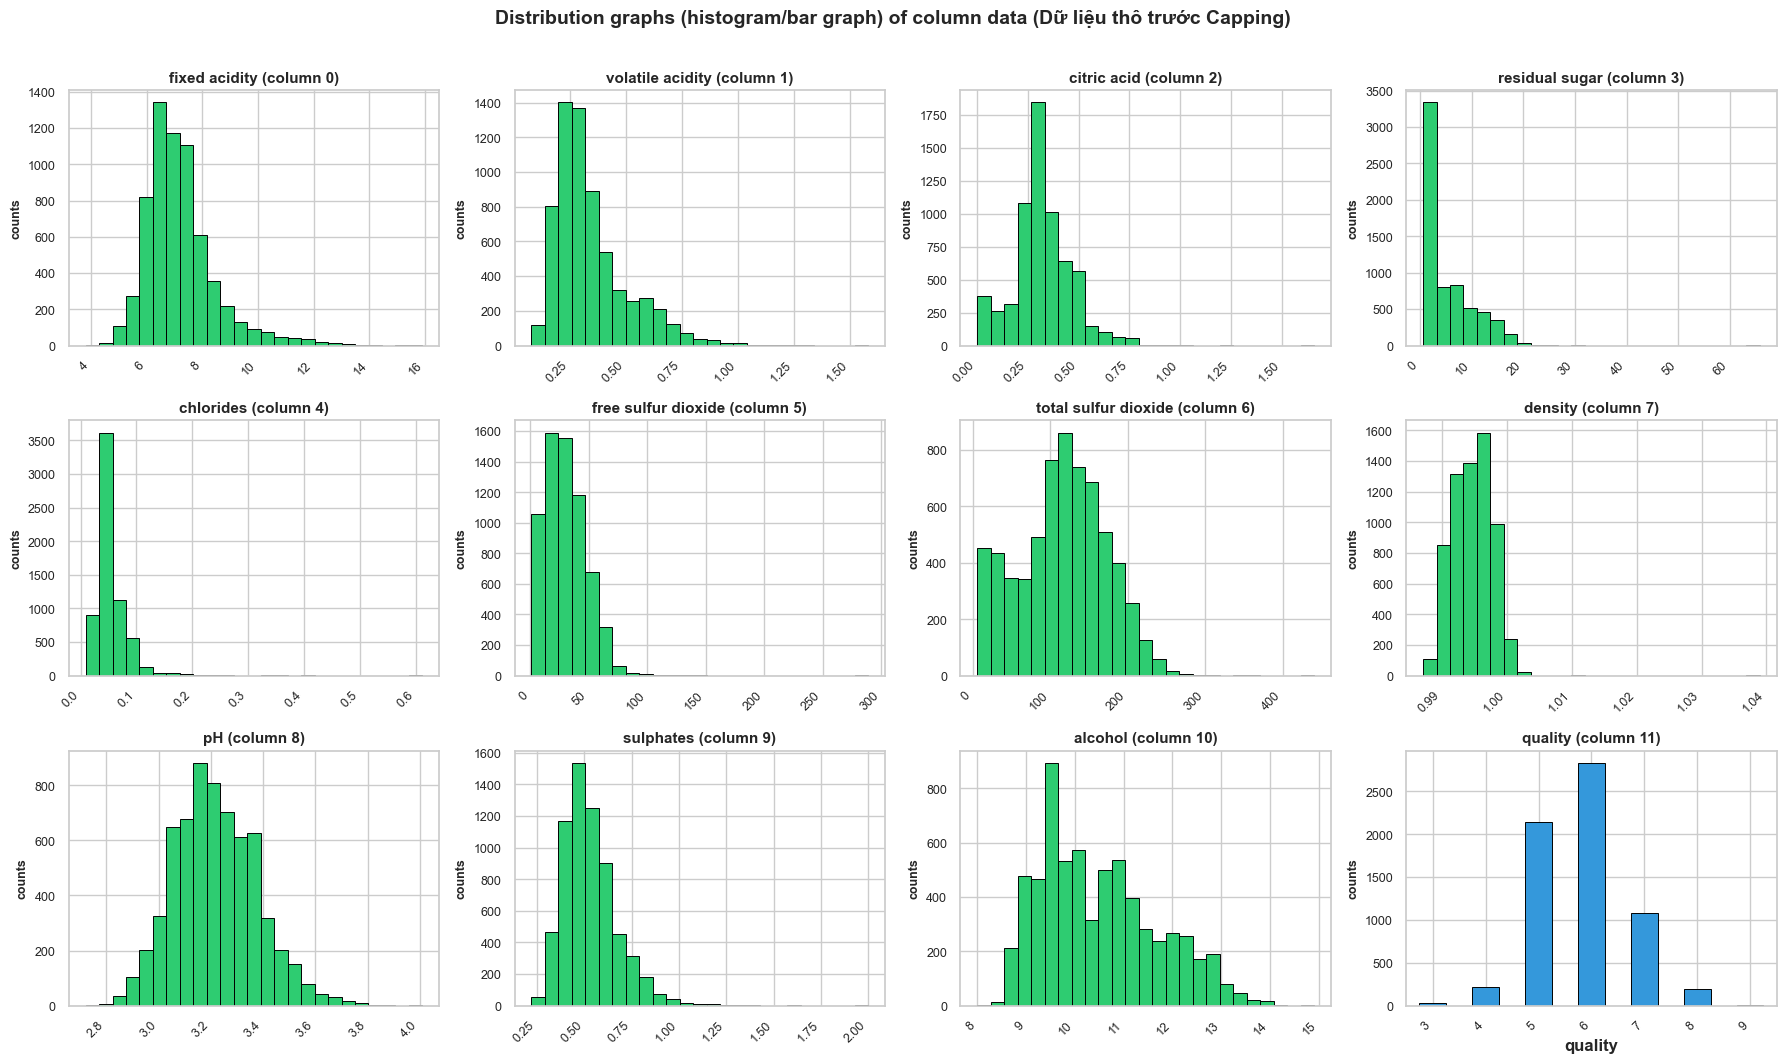

In [1]:
plotPerColumnDistribution(df_goc, 12, 4)

## Bước 3: Chuẩn Hóa Tên Cột Sang Tiếng Việt
Ánh xạ các tên chỉ số hóa lý tiếng Anh sang danh pháp tiếng Việt chuẩn hóa khoa học.

In [1]:
df_tieng_viet = chuan_hoa_ten_cot(df_goc)
df_tieng_viet.head(3)

,axit_co_dinh,axit_bay_hoi,axit_citric,duong_du,muoi_clorua,so2_tu_do,so2_tong,ti_trong,do_ph,sunfat,do_con,diem_chat_luong,loai_ruou
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Vang đỏ
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Vang đỏ
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Vang đỏ


## Bước 4: Đánh Giá Chất Lượng Dữ Liệu (Missing Values & Duplicates)

In [1]:
bao_cao_cl = kiem_tra_chat_luong_du_lieu(df_tieng_viet)
print(f"- Tổng số mẫu rượu: {bao_cao_cl['tong_so_dong']}")
print(f"- Số dòng trùng lặp: {bao_cao_cl['so_dong_trung_lap']} ({bao_cao_cl['ti_le_trung_lap']}%)")
print(f"- Cột bị thiếu dữ liệu: {bao_cao_cl['cot_thieu_du_lieu'] if bao_cao_cl['cot_thieu_du_lieu'] else 'Không có (Dữ liệu đầy đủ 100%)'}")

- Tổng số mẫu rượu: 6497
- Số dòng trùng lặp: 1177 (18.12%)
- Cột bị thiếu dữ liệu: Không có (Dữ liệu đầy đủ 100%)


## Bước 5: Xử Lý Ngoại Lai Bằng Winsorization / Capping (1% - 99%)
Bảo tồn 100% mẫu quan sát bằng cách giới hạn các ngoại lai cực đoan về ngưỡng phân vị 1% và 99%.

In [1]:
df_capped, thong_tin_nguong = xu_ly_ngoai_lai_capping(
    df_tieng_viet,
    danh_sach_cot=CAC_COT_HOA_LY,
    phan_vi_duoi=0.01,
    phan_vi_tren=0.99
)
pd.DataFrame(thong_tin_nguong).T

,nguong_duoi,nguong_tren,so_mau_bi_cat_duoi,so_mau_bi_cat_tren
axit_co_dinh,5.1000,12.0000,63.0,60.0
axit_bay_hoi,0.1200,0.8800,34.0,62.0
axit_citric,0.0000,0.7400,0.0,29.0
duong_du,0.9000,18.2000,34.0,63.0
muoi_clorua,0.0210,0.1862,58.0,65.0
so2_tu_do,4.0000,77.0000,64.0,62.0
so2_tong,11.0000,238.0000,64.0,61.0
ti_trong,0.9889,1.0006,64.0,58.0
do_ph,2.8900,3.6400,58.0,64.0
sunfat,0.3000,0.9900,52.0,63.0


## Bước 6: Trực Quan Hóa Phân Phối Sau Khi Xử Lý Ngoại Lai
Đối chiếu với biểu đồ ở Bước 2, các giá trị ngoại lai cực đoan đã được co về ngưỡng an toàn, phân phối trở nên hài hòa và mượt mà hơn.

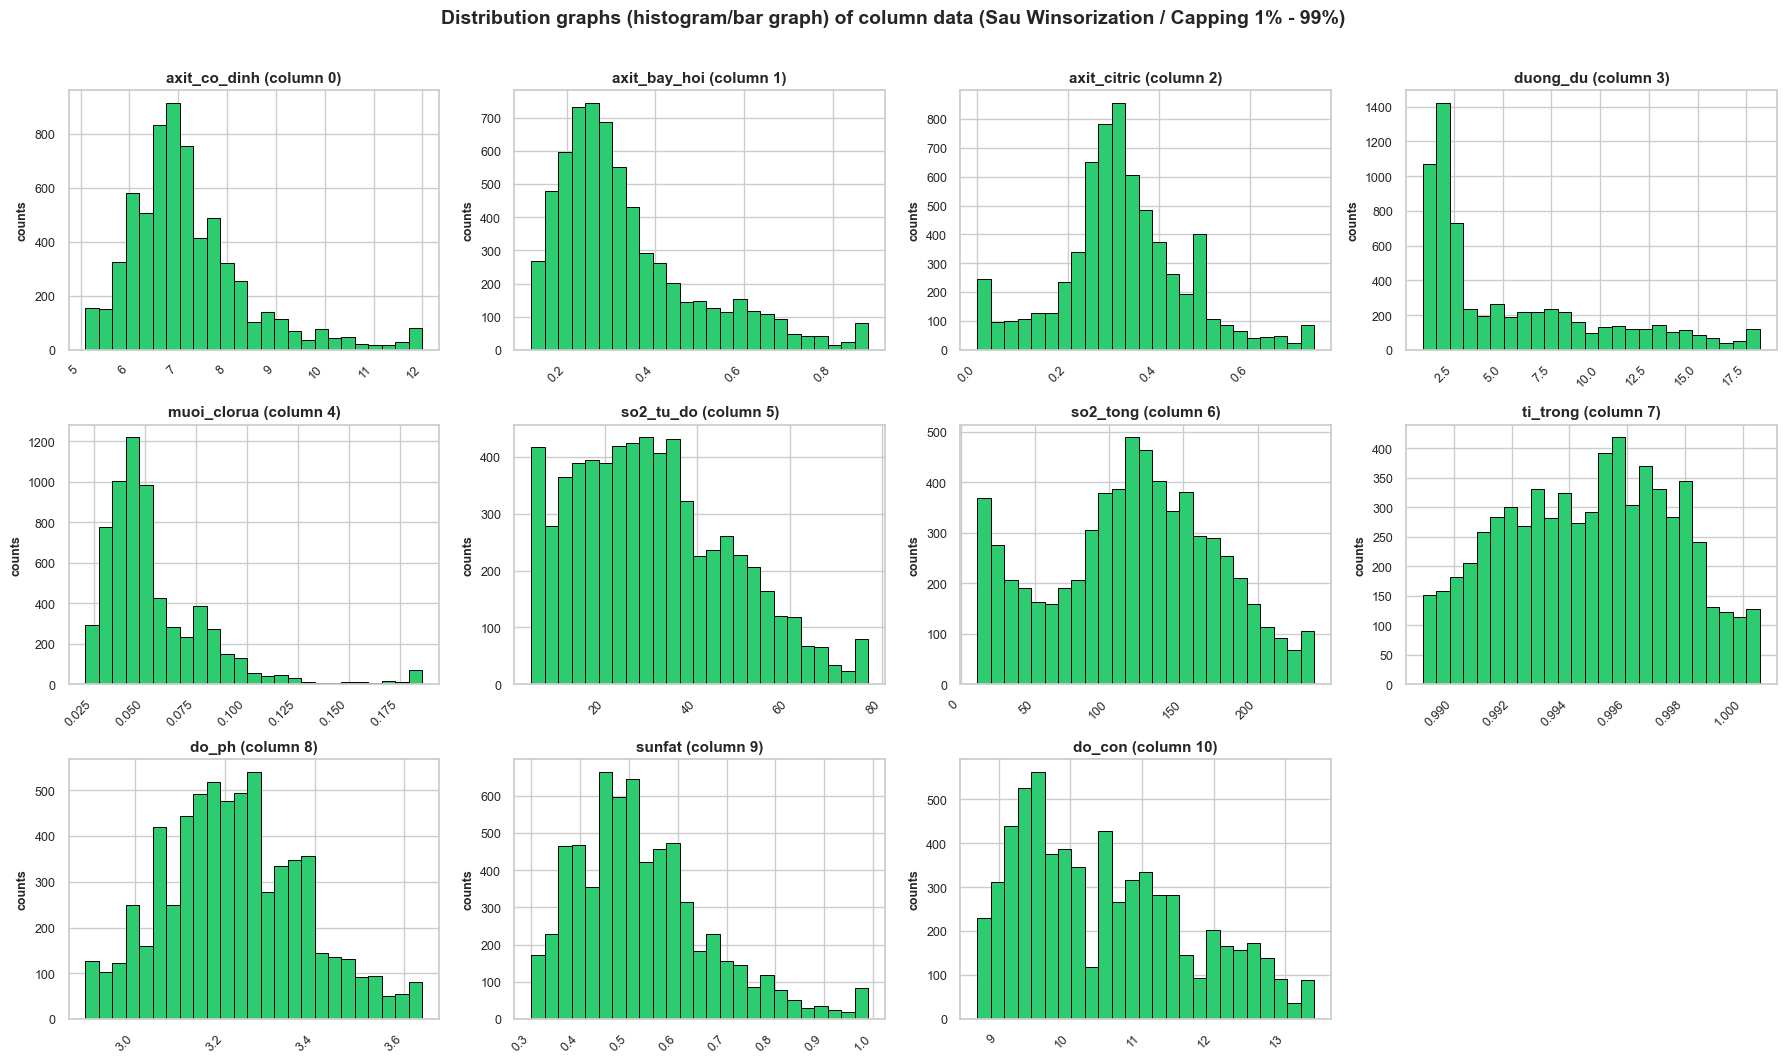

In [1]:
plotPerColumnDistribution(df_capped[CAC_COT_HOA_LY], 12, 4)

## Bước 7: Phân Nhóm 3 Bậc Chất Lượng Rượu Vang
- **Kém (Low):** Điểm $3 - 4$
- **Trung bình (Medium):** Điểm $5 - 6$
- **Thượng hạng (High):** Điểm $7 - 9$

In [1]:
df_chuan = tao_bien_phan_bac_chat_luong(df_capped)
thong_ke = pd.DataFrame({
    'Số lượng': df_chuan['bac_chat_luong'].value_counts(),
    'Tỷ lệ (%)': (df_chuan['bac_chat_luong'].value_counts(normalize=True) * 100).round(2)
})
thong_ke

,count
bac_chat_luong,
Trung bình,4974
Thượng hạng,1277
Kém,246


## Bước 8: Lưu Trữ Dữ Liệu Chuẩn Hóa Sang Feather
Lưu trữ vào `data/duleu_chuan.feather` để phục vụ EDA và đối sánh thống kê.

In [1]:
duong_dan = luu_du_lieu_chuan(df_chuan)
print(f"Đã lưu thành công dữ liệu chuẩn hóa vào: {duong_dan}")

[INFO] Đã lưu dữ liệu chuẩn hóa (6497 dòng, 16 cột) vào: d:\data_science\bom_ruou\data\duleu_chuan.feather
Đã lưu thành công dữ liệu chuẩn hóa vào: d:\data_science\bom_ruou\data\duleu_chuan.feather
